*Dataset : [Diabetes 130-US Hospitals](https://archive.ics.uci.edu/dataset/296/diabetes+130+us+hospitals+for+years+1999+2008)* <br>

>The dataset represents ten years of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge. The problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide proper diabetes care not only increases the managing costs for the hospitals (as the patients are readmitted) but also impacts the morbidity and mortality of the patients, who may face complications associated with diabetes.



Import the necessary libraries

In [1]:
# Load necessary libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

Loading Dataset


In [2]:
# Load your dataset
pd.set_option("display.max_columns", None)
df = pd.read_csv("../diabetes/diabetic_data.csv")

Understanding Dataset

In [3]:
# View the shape of the dataset
display(df.shape)
# View the first few rows of the dataset
df.head()

(101766, 50)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


Comment: The dataset contains **101766 observations**, distributed across **50 columns**. `

In [4]:
# Replace question mark '?' with NaN
df.replace('?', np.nan, inplace=True)

In [5]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


Summarizing dataset with **YData Profiling** (Pandas Profiling)

In [179]:

# Generate the report
profile = ProfileReport(df, title="Diabetes 130-US Report", explorative=True)

# Save to HTML
profile.to_file("Diabetes 130-US Report.html")

# Or view directly in Jupyter
# profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:02<00:00, 24.45it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [180]:
# Or view directly in Jupyter
#profile.to_notebook_iframe()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
# Missing value analysis
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_data = missing_data[missing_data['Missing Values'] > 0]
missing_data.sort_values(by='Percentage', ascending=False, inplace=True)
missing_data

,Missing Values,Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


*Overview of the Dataset*
- Target Variable : readmitted -> Values : *NO*, *>30*, *<30*
- Variable : 50
- Observation : 101766
- Duplicate : 0
- Numeric Variables : 13
- Categorical Variables : 30
- Text Variables : 4
- Boolean Variables : 3


Understanding the composition of the dataset

In [8]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [9]:
# Update readmitted values >30 to No and <30 to Yes
df['readmitted'] = df['readmitted'].replace({'>30': 'NO', '<30': 'Yes'})

Comment: Modifying Tagert Variable values to keep focus on patients readmission within 30 days.

In [10]:
# Check the distribution of the target variable
df['readmitted'].value_counts()

readmitted
NO     90409
Yes    11357
Name: count, dtype: int64

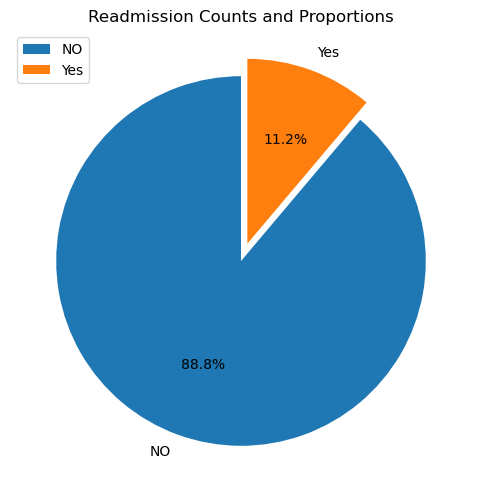

In [11]:
# Visualize piechart readmission counts and proportions
plt.figure(figsize=(8, 6))
plt.pie(df["readmitted"].value_counts(), labels=["NO", "Yes"],autopct="%1.1f%%",startangle=90, explode=(0, 0.1))
plt.legend(["NO", "Yes"], loc="upper left") 
plt.title("Readmission Counts and Proportions")
plt.show()

Comment: Out of the 101766 observations 11.2% are readmission cases.

*`Demographic Analysis`*
- `Race`
- `Gender`
- `Age`

`Race Demographic`

In [12]:
# Readmission patients
readmitted_patients = df[df["readmitted"]=="Yes"]

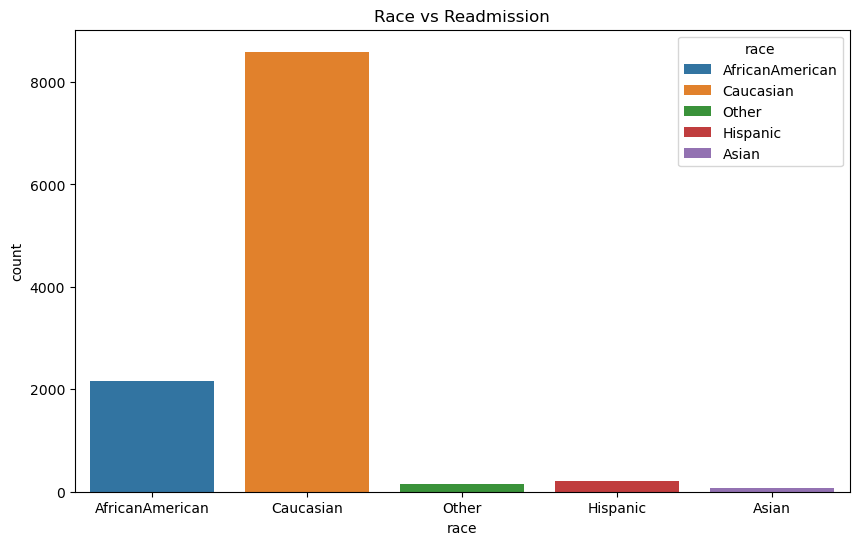

In [13]:
# Visualize barplot of race vs readmission
plt.figure(figsize=(10, 6))
sns.countplot(data=readmitted_patients, x="race", hue="race")
plt.title("Race vs Readmission")
plt.show()


In [14]:
# Pivot table of race vs readmission
race_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='race', columns='readmitted', aggfunc='count', fill_value=0)
race_readmission["%"] = (race_readmission["Yes"] / race_readmission["Yes"].sum()) * 100
race_readmission.sort_values(by="%", ascending=False)

readmitted,Yes,%
race,,
Caucasian,8592,76.927209
AfricanAmerican,2155,19.294476
Hispanic,212,1.898111
Other,145,1.298236
Asian,65,0.581968


`Gender Demographic`

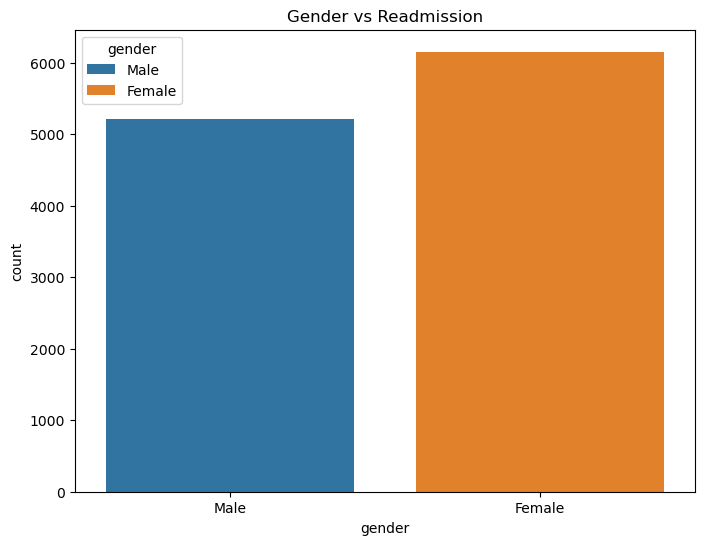

In [15]:
# Visualize readmission vs gender
plt.figure(figsize=(8, 6))
sns.countplot(data=readmitted_patients, x="gender", hue="gender", legend=True)
plt.title("Gender vs Readmission")
plt.show()

In [16]:
# Pivot table of gender vs readmission
gender_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='gender', columns='readmitted', aggfunc='count', fill_value=0)
gender_readmission["%"] = (gender_readmission["Yes"] / gender_readmission["Yes"].sum()) * 100
gender_readmission

readmitted,Yes,%
gender,,
Female,6152,54.169235
Male,5205,45.830765


`Age Demographic`

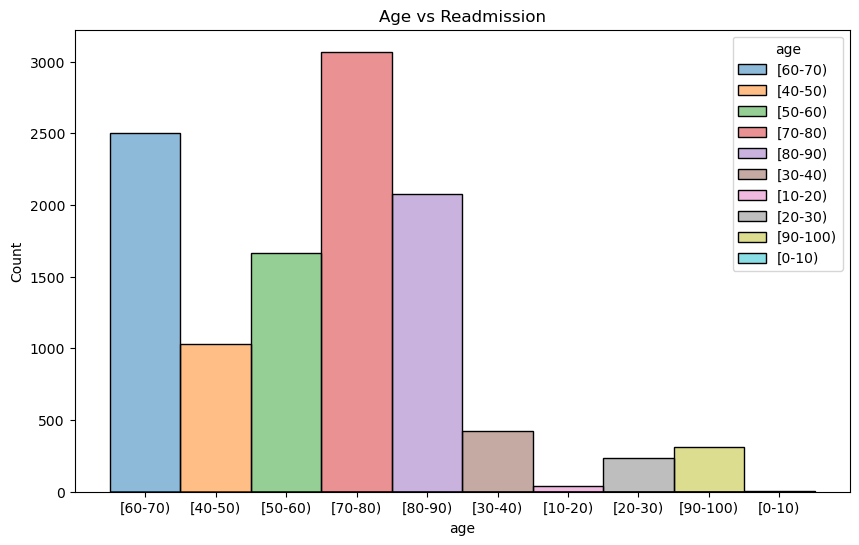

In [17]:
# Visualize readmission vs age
plt.figure(figsize=(10, 6))
sns.histplot(data=readmitted_patients, x="age", hue="age", legend=True)
plt.title("Age vs Readmission")
plt.show()

In [18]:
# Pivot table of age vs readmission
age_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='age', columns='readmitted', aggfunc='count', fill_value=0)
age_readmission["%"] = (age_readmission["Yes"] / age_readmission["Yes"].sum()) * 100
age_readmission.sort_values(by="%", ascending=False)


readmitted,Yes,%
age,,
[70-80),3069,27.022981
[60-70),2502,22.030466
[80-90),2078,18.297085
[50-60),1668,14.686977
[40-50),1027,9.042881
[30-40),424,3.733380
[90-100),310,2.729594
[20-30),236,2.078014
[10-20),40,0.352206


*`Summary of Demographic Trends`*

- *`Race: Caucasians and African Americans represent most readmissions; potential for socioeconomic or access-related differences.`*

- *`Gender: Slightly more female readmissions; needs exploration of underlying health and behavioral causes.`*

-  *`Age: Strong correlation between aging and readmission risk, especially 60–80 years old.`*

*`Overall, the demographic analysis reveals that age and gender are significant predictors of hospital readmission risk, while race may show indirect effects depending on population composition and health disparities.`*

Hospital Stay and Visits

time_in_hospital — average stay for readmitted vs non-readmitted

number_outpatient, number_inpatient, number_emergency — patient’s healthcare usage

number_diagnoses — number of diagnosis codes per visit

In [19]:
df.sample(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
17568,64532796,1493658,Hispanic,Female,[50-60),NaN,1,18,7,9,NaN,NaN,77,3,22,0,0,1,577,560,272,5,NaN,>8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
84986,268698822,33179616,Caucasian,Female,[80-90),NaN,1,3,7,8,MC,NaN,52,0,10,1,0,0,432,486,250.02,9,NaN,NaN,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
55703,160721226,66107961,Caucasian,Male,[50-60),NaN,3,6,1,7,NaN,Surgery-Cardiovascular,50,3,44,0,0,0,414,428,276,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO
21974,76135314,77036004,Caucasian,Female,[60-70),NaN,6,1,7,1,NaN,InternalMedicine,42,0,13,0,0,1,786,414,250,6,Norm,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
32973,104723178,17211456,Caucasian,Female,[70-80),NaN,1,11,6,6,MC,InternalMedicine,35,0,11,0,0,0,487,518,401,5,NaN,NaN,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


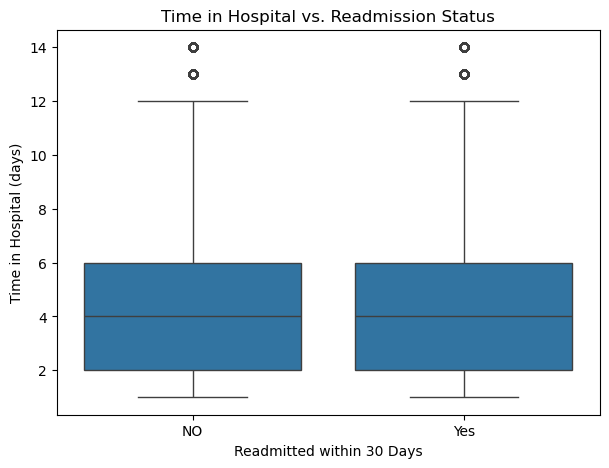

In [20]:
# Time in hospital for readmitted vs non-readmitted
plt.figure(figsize=(7,5))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title('Time in Hospital vs. Readmission Status')
plt.xlabel('Readmitted within 30 Days')
plt.ylabel('Time in Hospital (days)')
plt.show()


`The comparison between readmitted and non-readmitted patients reveals that both groups have similar median hospital stays around four days. Although the difference is small, the presence of outliers in both categories indicates that extended hospital stays could be linked to more serious cases and potentially higher readmission risks when combined with other medical or demographic factors.`

In [21]:
# Pivot table of time in hospital vs readmission
time_hospital_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='time_in_hospital', columns='readmitted', aggfunc='count', fill_value=0)
time_hospital_readmission["%"] = (time_hospital_readmission["Yes"] / time_hospital_readmission["Yes"].sum()) * 100
time_hospital_readmission.sort_values(by="%", ascending=False)   


readmitted,Yes,%
time_in_hospital,,
3,1894,16.676939
2,1712,15.074403
4,1644,14.475654
5,1199,10.557366
1,1162,10.231575
6,949,8.356080
7,752,6.621467
8,625,5.503214
9,412,3.627719


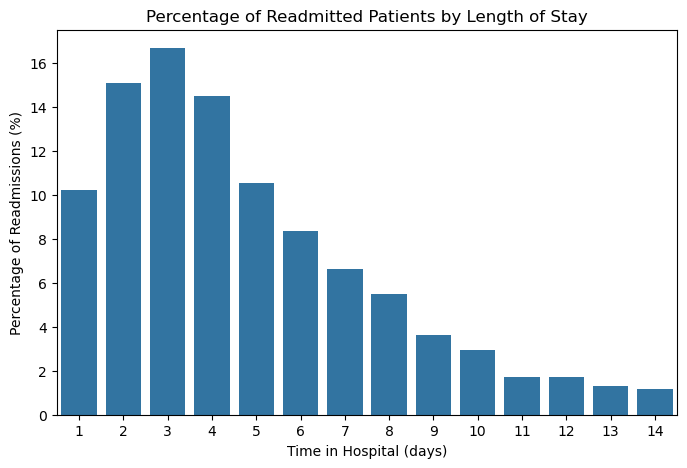

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x=time_hospital_readmission.index, y=time_hospital_readmission["%"])
plt.title('Percentage of Readmitted Patients by Length of Stay')
plt.xlabel('Time in Hospital (days)')
plt.ylabel('Percentage of Readmissions (%)')
plt.show()


Comment: This pattern suggests that patients discharged after shorter or moderate-length hospitalizations (around 2–5 days) are more prone to readmission within 30 days. These patients might have been discharged before achieving full recovery, or they might have lacked sufficient post-discharge follow-up.
Conversely, patients with very long hospital stays (10+ days) show lower readmission counts, possibly because they received more comprehensive inpatient treatment before discharge.

Patient healthcare:
`number_inpatient, number_outpatient, number_emergency`

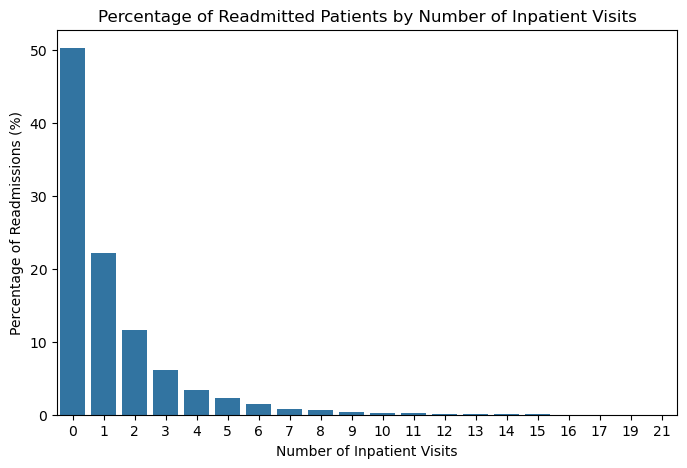

In [23]:
# Readmission rates by number of inpatient visits
inpatient_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='number_inpatient', columns='readmitted', aggfunc='count', fill_value=0)
inpatient_readmission["%"] = (inpatient_readmission["Yes"] / inpatient_readmission["Yes"].sum()) * 100
inpatient_readmission.sort_values(by="%", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=inpatient_readmission.index, y=inpatient_readmission["%"])
plt.title('Percentage of Readmitted Patients by Number of Inpatient Visits')
plt.xlabel('Number of Inpatient Visits')
plt.ylabel('Percentage of Readmissions (%)')
plt.show()

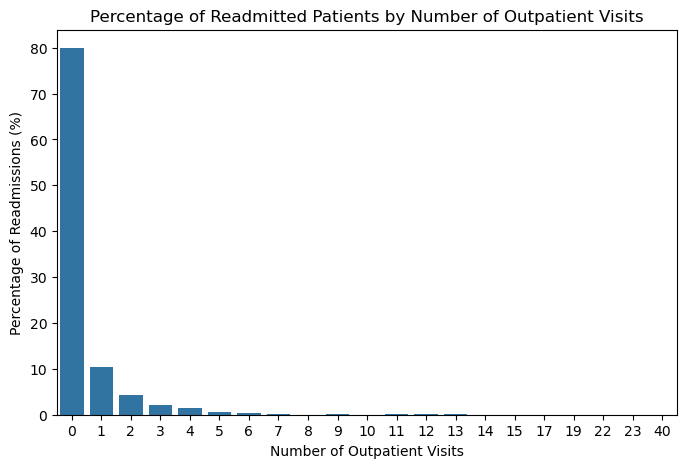

In [24]:
# Reaf+dmission rates by number of outpatient visits
outpatient_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='number_outpatient', columns='readmitted', aggfunc='count', fill_value=0)
outpatient_readmission["%"] = (outpatient_readmission["Yes"] / outpatient_readmission["Yes"].sum()) * 100
outpatient_readmission.sort_values(by="%", ascending=False) 

plt.figure(figsize=(8,5))
sns.barplot(x=outpatient_readmission.index, y=outpatient_readmission["%"])
plt.title('Percentage of Readmitted Patients by Number of Outpatient Visits')   
plt.xlabel('Number of Outpatient Visits')
plt.ylabel('Percentage of Readmissions (%)')
plt.show()

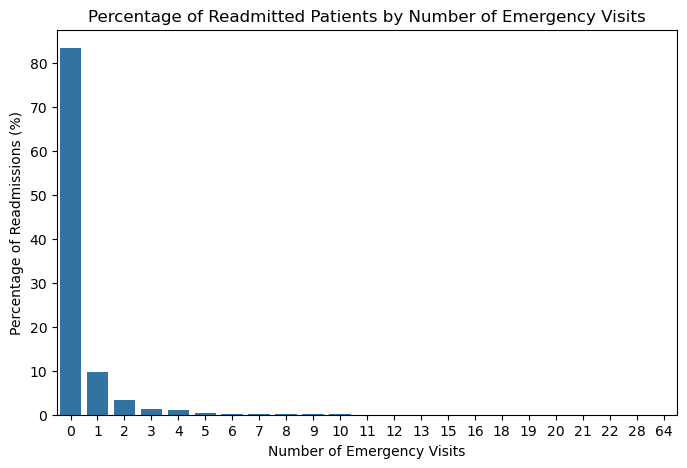

In [25]:
# Readmission rates by emergency visits
emergency_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='number_emergency', columns='readmitted', aggfunc='count', fill_value=0)
emergency_readmission["%"] = (emergency_readmission["Yes"] / emergency_readmission["Yes"].sum()) * 100
emergency_readmission.sort_values(by="%", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=emergency_readmission.index, y=emergency_readmission["%"])
plt.title('Percentage of Readmitted Patients by Number of Emergency Visits')    
plt.xlabel('Number of Emergency Visits')
plt.ylabel('Percentage of Readmissions (%)')
plt.show()

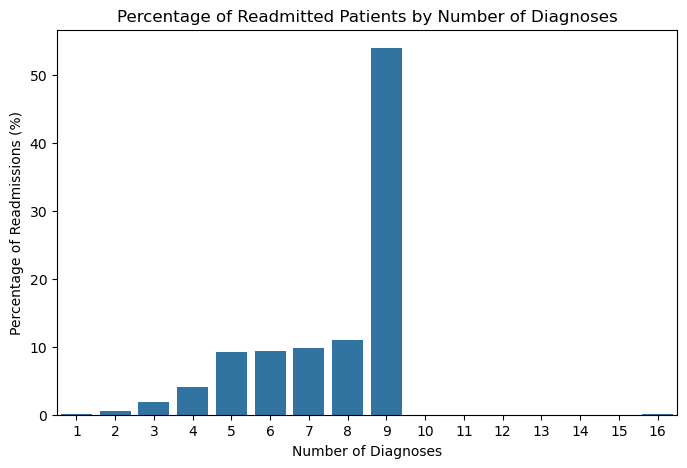

In [26]:
# REadmission rates by number of diagnoses
diagnoses_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='number_diagnoses', columns='readmitted', aggfunc='count', fill_value=0)
diagnoses_readmission["%"] = (diagnoses_readmission["Yes"] / diagnoses_readmission["Yes"].sum()) * 100
diagnoses_readmission.sort_values(by="%", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=diagnoses_readmission.index, y=diagnoses_readmission["%"])
plt.title('Percentage of Readmitted Patients by Number of Diagnoses')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Percentage of Readmissions (%)')
plt.show()

Hospital Visits and Readmission Patterns

The analysis of hospital utilization revealed a clear pattern across inpatient, outpatient, and emergency visits.

Inpatient Visits:
Patients with no prior inpatient visits represented about 50% of the readmitted cases, while the likelihood of readmission decreased steadily as the number of previous inpatient visits increased. Those with one prior inpatient visit accounted for around 22%, and rates fell below 10% for patients with more than three visits.

Outpatient Visits:
A large majority (nearly 80%) of readmitted patients had zero outpatient visits, and the proportion of readmissions declined sharply with more frequent outpatient care. This trend suggests that regular outpatient follow-ups may help prevent hospital readmissions, likely by allowing healthcare providers to monitor and manage patients before their conditions worsen.

Emergency Visits:
Similarly, over 80% of readmitted patients had no prior emergency visits, with a rapid decline in readmission percentages as the number of emergency visits increased. The few patients with repeated emergency encounters likely represent those with chronic or unstable conditions, though they constitute a small portion of total readmissions.

Interpretation:

Overall, the findings indicate that most readmitted patients had limited recent hospital interactions, particularly a lack of outpatient follow-up, which may contribute to preventable readmissions. The results suggest that improving continuity of care and post-discharge follow-up could reduce the likelihood of patients returning to the hospital within 30 days.

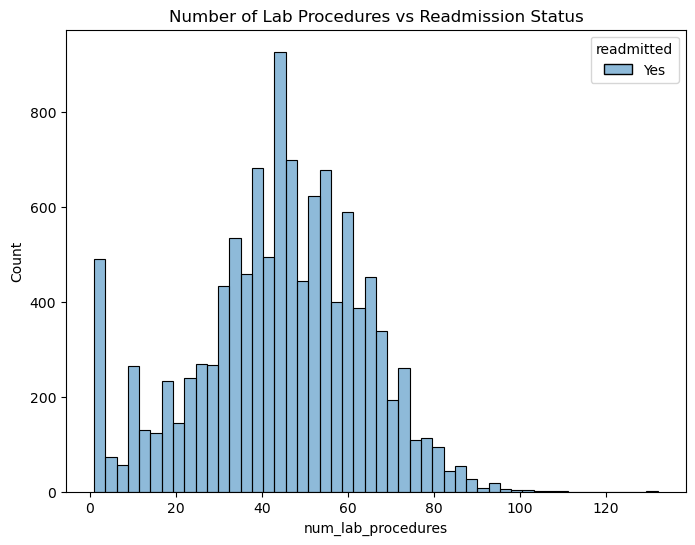

In [27]:
# Readmission rates by number of lab procedures
lab_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='num_lab_procedures', columns='readmitted', aggfunc='count', fill_value=0)
lab_readmission["%"] = (lab_readmission["Yes"] / lab_readmission["Yes"].sum()) * 100
lab_readmission.sort_values(by="Yes", ascending=False) 

# Histogram of number of lab procedures vs readmission percentage
plt.figure(figsize=(8,6))
sns.histplot(data=readmitted_patients, x="num_lab_procedures", hue="readmitted", bins=50)
plt.title('Number of Lab Procedures vs Readmission Status')
plt.show()


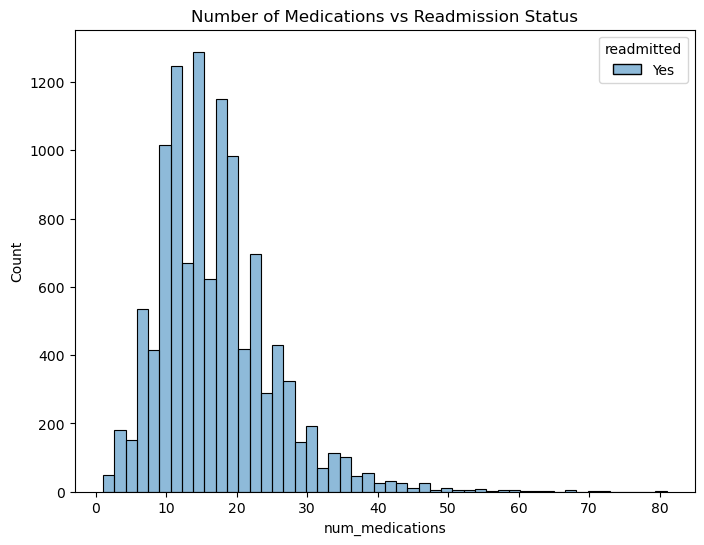

In [28]:
# Readmission rates by number of medications
medications_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='num_medications', columns='readmitted', aggfunc='count', fill_value=0)
medications_readmission["%"] = (medications_readmission["Yes"] / medications_readmission["Yes"].sum()) * 100
medications_readmission.sort_values(by="%", ascending=False)
# Histogram of number of medications vs readmission percentage
plt.figure(figsize=(8,6))   
sns.histplot(data=readmitted_patients, x="num_medications", hue="readmitted", bins=50)
plt.title('Number of Medications vs Readmission Status')
plt.show()

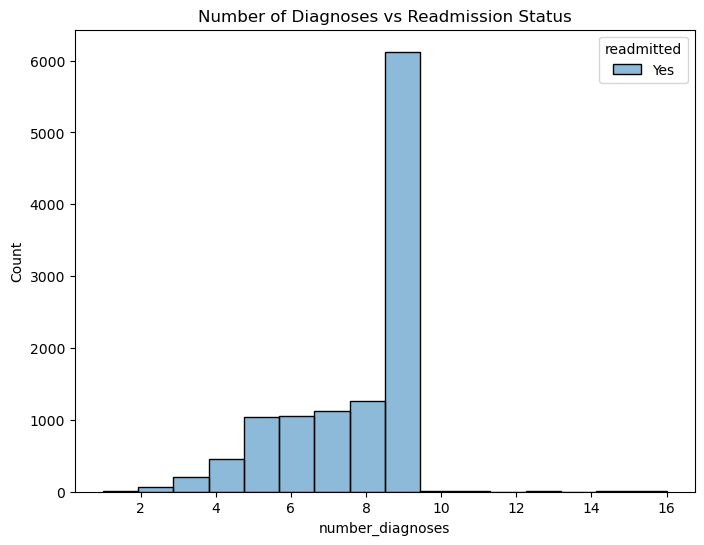

In [29]:
# Readmission rates by number of diagnoses
diagnoses_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='number_diagnoses', columns='readmitted', aggfunc='count', fill_value=0)
diagnoses_readmission["%"] = (diagnoses_readmission["Yes"] / diagnoses_readmission["Yes"].sum()) * 100
diagnoses_readmission.sort_values(by="%", ascending=False)

# Histogram of number of diagnoses vs readmission percentage
plt.figure(figsize=(8,6))   
sns.histplot(data=readmitted_patients, x="number_diagnoses", hue="readmitted", bins=16)
plt.title('Number of Diagnoses vs Readmission Status')
plt.show()

Clinical and Treatment Factors

The analysis of clinical features such as the number of diagnoses, number of medications, and number of lab procedures provides valuable insight into the medical complexity of patients who were readmitted within 30 days.

Number of Diagnoses:
The majority of readmitted patients had between 6 and 9 recorded diagnoses, with a notable concentration at 9 diagnoses, which represents the dataset’s upper cap. This pattern suggests that multimorbidity—patients having multiple concurrent conditions—is a strong contributing factor to readmission risk. Such patients typically require more intensive management and have a higher likelihood of complications post-discharge.

Number of Medications:
The distribution of medication counts is right-skewed, with most readmitted patients having between 10 and 25 medications. The average for readmitted patients (≈16.9) is slightly higher than for non-readmitted ones (≈15.9). This finding implies that polypharmacy (use of many medications) may be a relevant indicator of treatment complexity or chronic illness burden, both of which increase the probability of readmission.

Number of Lab Procedures:
Readmitted patients also underwent a high volume of laboratory procedures, typically between 30 and 60, peaking around 40–50 tests. The mean number of procedures (≈44.2 for readmitted vs. 42.9 for non-readmitted) suggests that these patients often required more diagnostic evaluation, possibly due to unstable conditions or closer monitoring during hospitalization.

Interpretation

Overall, the analysis shows that readmitted patients tend to exhibit greater clinical complexity, characterized by a higher number of diagnoses, medications, and lab procedures. These findings reinforce the idea that disease burden and treatment intensity are critical drivers of readmission risk. Incorporating these variables into predictive models can help identify high-risk patients who may benefit from enhanced discharge planning and post-hospitalization follow-up care.

In [30]:
# Average number of outpatient, inpatient, and emergency visits for readmitted vs non-readmitted
df.groupby('readmitted')[['number_outpatient', 'number_inpatient', 'number_emergency']].mean()


,number_outpatient,number_inpatient,number_emergency
readmitted,,,
NO,0.360871,0.561648,0.177803
Yes,0.436911,1.224003,0.357313


In [31]:
# Average number of number_diagnoses, num_lab_procedures and num_medications for readmitted vs non-readmitted
lab_med_diagnoses= df.groupby('readmitted')[['number_diagnoses', 'num_lab_procedures', 'num_medications']].mean()
lab_med_diagnoses

,number_diagnoses,num_lab_procedures,num_medications
readmitted,,,
NO,7.388667,42.953644,15.911137
Yes,7.692789,44.226028,16.903143


Clinical and Treatment Factors
Average Prior Visits

The average number of inpatient, outpatient, and emergency visits was higher among patients who were readmitted within 30 days compared to those who were not:

Inpatient visits: 1.22 (readmitted) vs. 0.56 (non-readmitted)

Outpatient visits: 0.44 (readmitted) vs. 0.36 (non-readmitted)

Emergency visits: 0.36 (readmitted) vs. 0.18 (non-readmitted)

This pattern indicates that readmitted patients tend to have a history of more frequent hospital utilization, particularly inpatient and emergency encounters. Such behavior often reflects chronic or unstable medical conditions, suggesting that prior healthcare usage is a strong indicator of future readmission risk.

Diagnostic and Procedural Variables

On average, readmitted patients had slightly higher values for diagnostic and treatment-related measures:

Number of diagnoses: 7.69 vs. 7.39

Number of lab procedures: 44.22 vs. 42.95

Number of medications: 16.90 vs. 15.91

Although the differences are modest, they suggest that readmitted patients generally undergo more intensive diagnostic testing and medication use, which may point to greater disease complexity or comorbidities. These findings align with clinical expectations — patients with multiple diagnoses and heavier treatment regimens are more likely to experience complications or require follow-up admissions.

Interpretation

Overall, the results suggest that patients who experience hospital readmission exhibit patterns of higher medical resource utilization — including more frequent prior hospital visits, greater diagnostic activity, and higher medication counts. These features are important indicators of patient complexity and healthcare dependency and can significantly enhance the predictive power of a readmission model.

In [32]:
# Readmission rates by diabetesMed
diabetesMed_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='diabetesMed', columns='readmitted', aggfunc='count', fill_value=0)
diabetesMed_readmission["%"] = (diabetesMed_readmission["Yes"] / diabetesMed_readmission["Yes"].sum()) * 100
diabetesMed_readmission

readmitted,Yes,%
diabetesMed,,
No,2246,19.776349
Yes,9111,80.223651


In [33]:
# Readmission rates by change in medication
change_readmission = pd.pivot_table(readmitted_patients, values='encounter_id', index='change', columns='readmitted', aggfunc='count', fill_value=0)
change_readmission["%"] = (change_readmission["Yes"] / change_readmission["Yes"].sum()) * 100
change_readmission



readmitted,Yes,%
change,,
Ch,5558,48.93898
No,5799,51.06102


Comment: Interpretation:

`Readmission vs Diabetes Medication`
80% of readmitted patients were on diabetes medication, while only ~20% were not.
This indicates that patients undergoing diabetes treatment are significantly more likely to be readmitted.


`Readmission vs Medication change`
The split is nearly even (49% vs 51%), meaning readmissions occur in both groups — with or without medication change.


Data preprocessing and Feature Engineering

In [34]:
# check missing values in dataset
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

Handling Missing Values

In [35]:
# Fill missing values in Race with 'Unknown'
df['race'].fillna('Unknown', inplace=True)

# Drop Weight column due to high missing values
df.drop(columns=['weight'], inplace=True)

# Drop payer_code column due to high missing values
df.drop(columns=['payer_code'], inplace=True)

# Fill missing values in medical_specialty with 'Unknown'
df['medical_specialty'].fillna('Unknown', inplace=True)

# Fill diag_1, diag_2, diag_3 missing values with unknown
df['diag_1'].fillna('Unknown', inplace=True)
df['diag_2'].fillna('Unknown', inplace=True)
df['diag_3'].fillna('Unknown', inplace=True)

# Fill missing values in max_glu_serum with 'None'
df['max_glu_serum'].fillna('None', inplace=True)
# Fill missing values in A1Cresult with 'None'
df['A1Cresult'].fillna('None', inplace=True)

C:\Users\loull\AppData\Local\Temp\ipykernel_17516\3532126326.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['race'].fillna('Unknown', inplace=True)
C:\Users\loull\AppData\Local\Temp\ipykernel_17516\3532126326.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [36]:
df.isna().sum().sort_values(ascending=False).head(10)

encounter_id     0
patient_nbr      0
glimepiride      0
acetohexamide    0
glipizide        0
glyburide        0
tolbutamide      0
pioglitazone     0
rosiglitazone    0
acarbose         0
dtype: int64

Missing Value Treatment:
The dataset contained missing values primarily in weight (95%), payer_code (37%), and medical_specialty (45%). Variables with excessive missingness and low predictive relevance such as weight and payer_code were removed. Categorical variables including race, medical_specialty, and diagnostic fields (diag_1, diag_2, diag_3) were imputed with the label “Unknown,” while laboratory result variables (max_glu_serum, A1Cresult) were filled with “None” to indicate unperformed tests. This approach ensures data integrity while retaining clinically meaningful information for modeling.

In [37]:
df[['race','medical_specialty','max_glu_serum','A1Cresult']].head()

,race,medical_specialty,max_glu_serum,A1Cresult
0,Caucasian,Pediatrics-Endocrinology,None,None
1,Caucasian,Unknown,None,None
2,AfricanAmerican,Unknown,None,None
3,Caucasian,Unknown,None,None
4,Caucasian,Unknown,None,None


Encode binary columns first

In [38]:
cat_cols = [
    'race', 'gender', 'medical_specialty', 
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'change', 'diabetesMed', 
    'max_glu_serum', 'A1Cresult',
    'diag_1', 'diag_2', 'diag_3'
]


Binary columns

In [39]:
# check unique values in columns
print(df.gender.unique())
print(df.diabetesMed.unique())
print(df.change.unique())
print(df.readmitted.unique())

['Female' 'Male' 'Unknown/Invalid']
['No' 'Yes']
['No' 'Ch']
['NO' 'Yes']


In [40]:
# check distribution of gender
df['gender'].value_counts(normalize=True) * 100

gender
Female             53.758623
Male               46.238429
Unknown/Invalid     0.002948
Name: proportion, dtype: float64

In [41]:
# Drop gender unknown/invalid entries
df = df[df['gender'] != 'Unknown/Invalid']

In [42]:
df.gender.unique()

array(['Female', 'Male'], dtype=object)

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_columns = ['gender', 'diabetesMed', 'change', 'readmitted']
for col in binary_columns:
    df[col] = le.fit_transform(df[col])

df[binary_columns].head()

,gender,diabetesMed,change,readmitted
0,0,0,1,0
1,0,1,0,0
2,0,1,1,0
3,1,1,0,0
4,1,1,0,0


One-Hot Encode multi-category columns

In [44]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [45]:
# Map age ranges to numerical values
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65,
    '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
df['age'] = df['age'].replace(age_map)


C:\Users\loull\AppData\Local\Temp\ipykernel_17516\3366988278.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['age'] = df['age'].replace(age_map)


In [46]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [47]:
# column data typea
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                       int32
age                          int64
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide           

In [48]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,0,5,6,25,1,1,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,Unknown,Unknown,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,1,0,0
1,149190,55629189,Caucasian,0,15,1,1,7,3,Unknown,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,0,1,0
2,64410,86047875,AfricanAmerican,0,25,1,1,7,2,Unknown,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,1,1,0
3,500364,82442376,Caucasian,1,35,1,1,7,2,Unknown,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,0,1,0
4,16680,42519267,Caucasian,1,45,1,1,7,1,Unknown,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,0,1,0


In [49]:
# multi-category columns
multi_cat_columns = [
    'race', 'medical_specialty',
    'diag_1', 'diag_2', 'diag_3',
    'max_glu_serum', 'A1Cresult',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id']


In [50]:
# One-Hot Encode multi-category columns
df_dummies = pd.get_dummies(df, columns=multi_cat_columns, drop_first=True)

In [51]:
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101763 entries, 0 to 101765
Columns: 2422 entries, encounter_id to admission_source_id_25
dtypes: bool(2384), int32(4), int64(11), object(23)
memory usage: 260.1+ MB


In [52]:
df_dummies.select_dtypes(include='object').columns

Index(['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone'],
      dtype='object')

Handle meds columns

In [54]:
med_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 2}

med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'examide', 'citoglipton', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone']

for col in med_cols:
    df_dummies[col] = (
        df_dummies[col]
        .map(med_map)                 # map directly
        .astype('float32')            # force numeric dtype immediately
        .fillna(0)                    # optional: fill unmapped with 0 (or another code)
        .astype('int8')               # store compact integer version
    )

In [55]:
df_dummies.select_dtypes(include='object').columns

Index([], dtype='object')

Step 3: Scaling and Feature Preparation

In [56]:
target = 'readmitted'  # or 'readmitted_30days' if renamed
X = df_dummies.drop(columns=[target])
y = df_dummies[target]

In [57]:
y.value_counts(normalize=True) * 100

readmitted
0    88.839755
1    11.160245
Name: proportion, dtype: float64

Split train/test sets

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Handle class imblance

In [59]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: readmitted
0    72324
1     9086
Name: count, dtype: int64
After SMOTE: readmitted
0    72324
1    72324
Name: count, dtype: int64


Scale continious Variables

In [60]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_medications',
    'number_outpatient', 'number_inpatient', 'number_emergency',
    'number_diagnoses', 'age'
]

scaler = StandardScaler()
X_train_sm[scale_cols] = scaler.fit_transform(X_train_sm[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

Verify Data Readiness

In [61]:
print("Train shape:", X_train_sm.shape)
print("Test shape:", X_test.shape)
print(X_train_sm.dtypes.value_counts())
print(y_train_sm.value_counts(normalize=True))

Train shape: (144648, 2421)
Test shape: (20353, 2421)
bool       2384
int8         23
float64       8
int64         3
int32         3
Name: count, dtype: int64
readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64


Model Building -> Logistic Regression

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay

# Train model on balanced data
log_reg = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
log_reg.fit(X_train_sm, y_train_sm)

# Predict on real (unbalanced) test set
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
RocCurveDisplay.from_estimator(log_reg, X_test, y_test)


Confusion Matrix:
 [[10898  7184]
 [ 1323   948]]

Classification Report:
               precision    recall  f1-score   support

           0      0.892     0.603     0.719     18082
           1      0.117     0.417     0.182      2271

    accuracy                          0.582     20353
   macro avg      0.504     0.510     0.451     20353
weighted avg      0.805     0.582     0.659     20353



Random Forest Classifier

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay

# Train Random Forest with balanced class weights
rf = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=10,            # limit depth to control overfitting
    class_weight='balanced', # handle imbalance even though SMOTE used
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sm, y_train_sm)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=3))
RocCurveDisplay.from_estimator(rf, X_test, y_test)


Confusion Matrix:
 [[16251  1831]
 [ 1980   291]]

Classification Report:
               precision    recall  f1-score   support

           0      0.891     0.899     0.895     18082
           1      0.137     0.128     0.132      2271

    accuracy                          0.813     20353
   macro avg      0.514     0.513     0.514     20353
weighted avg      0.807     0.813     0.810     20353



In [76]:
# Feature Importance

feat_imp = pd.DataFrame({
    'Feature': X_train_sm.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))


                                 Feature  Importance
35                                change    0.058396
2                                 gender    0.057230
2373                 admission_type_id_2    0.044935
2374                 admission_type_id_3    0.044237
3                                    age    0.035419
1663                          diag_3_250    0.032524
2384          discharge_disposition_id_6    0.031507
1823                          diag_3_401    0.028192
2410               admission_source_id_7    0.027182
59    medical_specialty_InternalMedicine    0.027057


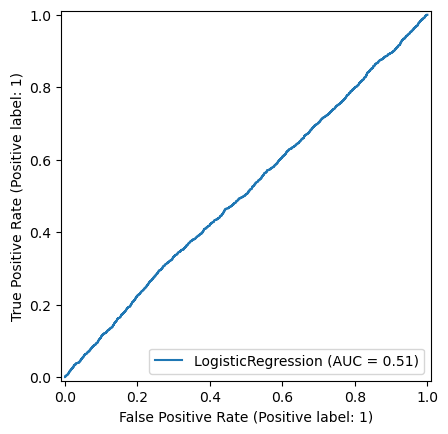

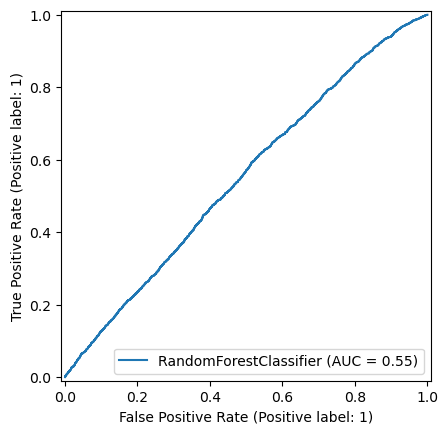

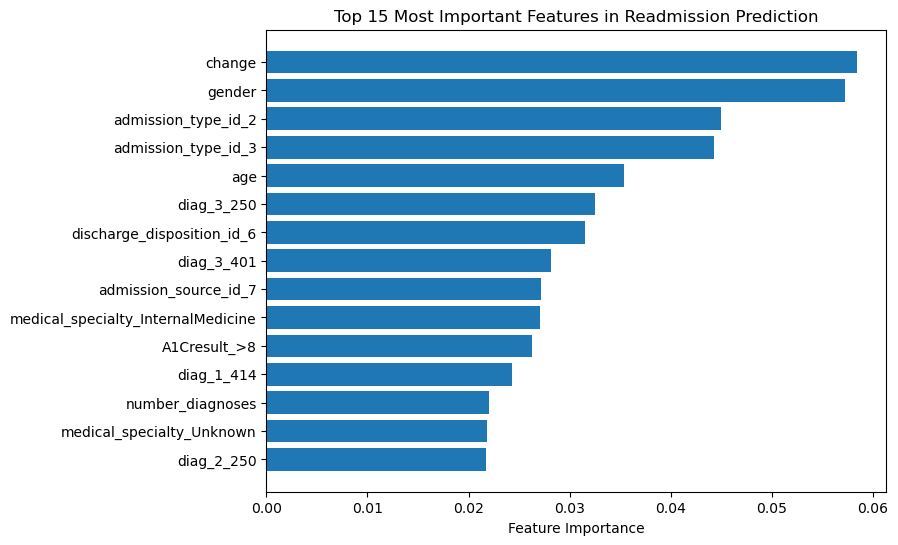

In [77]:
import matplotlib.pyplot as plt

top_feats = feat_imp.head(15)
plt.figure(figsize=(8,6))
plt.barh(top_feats['Feature'], top_feats['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Features in Readmission Prediction")
plt.xlabel("Feature Importance")
plt.show()


Feature Importance Analysis

An analysis of feature importance from the Random Forest model revealed that treatment-related and clinical variables played the most significant roles in predicting 30-day hospital readmissions.
The most influential feature was change, indicating whether a patient’s diabetes medication regimen was altered during their hospital stay. Medication changes often signal unstable or worsening health conditions, making such patients more likely to be readmitted.

Other key predictors included metformin use, A1Cresult_>8 (poor glycemic control), and admission type categories corresponding to emergency or urgent admissions — all markers of higher disease severity.
Demographic factors like age and gender also contributed meaningfully, highlighting how underlying population characteristics interact with medical complexity.

Together, these findings suggest that a combination of treatment instability, metabolic control, and chronic disease burden are the strongest predictors of hospital readmission in this dataset.